# **Initial data import and formatting**

In [ ]:
#step 1 get data in format
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats.mstats import winsorize

data = pd.read_excel(r'/content/drive/MyDrive/data/Urpp proc.xlsx', header = 3, sheet_name=None)
search_key = '31-35'
agent_all = {}
self_int_all = {}
# loop through the dictionary and save csv
for sheet_name, df in data.items():
  if search_key in sheet_name:
    agent_all[sheet_name] = df
  else:
    self_int_all[sheet_name]=df


for sheet_name, df in agent_all.items():
  df['Normalized RT']= winsorize(df['Reaction Time'], limits=[0.05, 0.06])

for sheet_name, df in self_int_all.items():
  df['Normalized RT']= winsorize(df['Reaction Time'], limits=[0.05, 0.06])

print(agent_all.keys())
print(self_int_all.keys())
df_far = agent_all.get('P1-31-35')
#df_far = agent.get('Far31-35')
print(df_far)

agent_matching = []
agent_count= []
self_matching = []
self_count = []

for sheet_name, df in agent_all.items():
  count =0
  for i in df.index:
    if ((df['Matches Audio'][i] == 'Matches') and (df['Matches Target'][i] == 'Matches')):
      count=count+1
  if(count>14):
    agent_matching.append(sheet_name)

for sheet_name, df2 in self_int_all.items():
  count2 =0

  for j in df2.index:
    if ((df2['Matches Audio'][j] == 'Matches') and (df2['Matches Target'][j] == 'Matches')):
      count2=count2+1
  if(count2>14):
    self_matching.append(sheet_name)

print(agent_matching)
print(self_matching)

agent = {}
self_int = {}
for i in agent_matching:
  for j in self_matching:
    if (i.split('-')[0] == j.split('-')[0]):
      #print("agent: "+ i +", self: "+j)
      agent[i] = agent_all[i]
      self_int[j] = self_int_all[j]

print(agent.keys())
print(self_int.keys())
print(len(self_int.keys()))

dict_keys(['P1-31-35', 'P2-31-35', 'P3-31-35', 'P4-31-35', 'P5-31-35', 'P6-31-35', 'P7-31-35', 'P8-31-35', 'P9-31-35', 'P10-31-35', 'P11-31-35', 'P12-31-35', 'P13-31-35', 'P14-31-35', 'P15-31-35', 'P16-31-35', 'P17-31-35', 'P18-31-35', 'P19-31-35', 'P20-31-35', 'P21-31-35', 'P22-31-35', 'P23-31-35', 'P24-31-35', 'P25-31-35', 'P26-31-35', 'P27-31-35', 'P28-31-35', 'P29-31-35', 'P30-31-35', 'P31-31-35', 'P32-31-35', 'P33-31-35', 'P34-31-35', 'P35-31-35', 'P36-31-35', 'P37-31-35', 'P38-31-35', 'P39-31-35', 'P40-31-35', 'P41-31-35', 'P42-31-35', 'P43-31-35', 'P44-31-35', 'P45-31-35', 'P46-31-35', 'P47-31-35', 'P48-31-35', 'P49-31-35', 'P50-31-35', 'P51-31-35', 'P52-31-35', 'P53-31-35'])
dict_keys(['P1-41-45', 'P2-41-45', 'P3-41-45', 'P4-41-45', 'P5-41-45', 'P6-41-45', 'P7-41-45', 'P8-41-45', 'P9-41-45', 'P10-41-45', 'P11-41-45', 'P12-41-45', 'P13-41-45', 'P14-41-45', 'P15-41-45', 'P16-41-45', 'P17-41-45', 'P18-41-45', 'P19-41-45', 'P20-41-45', 'P21-41-45', 'P22-41-45', 'P23-41-45', 'P24-41

# **Repeated measures one way anova**

In [ ]:
import pandas as pd
df_xform=pd.DataFrame(columns=['Participant_ID', 'Video', 'Audio', 'nAud', 'nVid', 'nNei'])
print(df_xform)

Target_name = ['Glass', 'Metal', 'Plastic', 'Wood']
Audio_name = ['Glass', 'Metal', 'Plastic', 'Wood']

for m in Target_name:
  for n in Audio_name:
    for sheet_name, df in agent.items():
      count_a = 0
      count_v = 0
      count_n = 0
      for i in df.index:
        if (df['Audio Source'][i] == n) & (df['Target'][i] == m):
          if (df['Matches Audio'][i] == 'Matches'):
            count_a = count_a + 1
          elif (df['Matches Target'][i]== 'Matches'):
            count_v = count_v + 1
          else:
            count_n = count_n + 1

      find_part = sheet_name.split('-')[0]

      for sheet_name2, df2 in self_int.items():
          if (sheet_name2.split('-')[0] == find_part):
            for j in df2.index:
              if (df2['Audio Source'][j] == n) & (df2['Target'][j] == m):
                if (df2['Matches Audio'][j] == 'Matches'):
                  count_a = count_a + 1
                elif (df2['Matches Target'][j]== 'Matches'):
                  count_v = count_v + 1
                else:
                  count_n = count_n + 1

      df_xform.loc[len(df_xform.index)] = [find_part, m, n, count_a, count_v, count_n]

print(df_xform)
# Filter rows to show only mismatch conditions
fil_df = df_xform[df_xform['Video'] != df_xform['Audio']]
fil_df.reset_index(drop=True, inplace=True)

##should i convert to % here?

Empty DataFrame
Columns: [Participant_ID, Video, Audio, nAud, nVid, nNei]
Index: []
    Participant_ID  Video  Audio  nAud  nVid  nNei
0               P1  Glass  Glass    13     0     7
1               P2  Glass  Glass    12     0     8
2               P4  Glass  Glass    18     0     2
3               P5  Glass  Glass    19     0     1
4               P6  Glass  Glass    12     0     8
..             ...    ...    ...   ...   ...   ...
667            P48   Wood   Wood    19     0     1
668            P49   Wood   Wood    20     0     0
669            P50   Wood   Wood    20     0     0
670            P51   Wood   Wood    19     0     1
671            P53   Wood   Wood    20     0     0

[672 rows x 6 columns]


In [ ]:
fil_df['Participant_ID'].value_counts()

,count
Participant_ID,
P1,12
P42,12
P32,12
P33,12
P34,12
P35,12
P37,12
P39,12
P40,12


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

unfixed = 'Audio'
fixed = 'Video'

val = 'Glass'
#val = 'Metal'
#val = 'Plastic'
#val = 'Wood'

subset_df = fil_df[fil_df[fixed]== val]
# Perform Repeated Measures one way ANOVA
print('When checking the responses matched to the Sound')
aovrm = AnovaRM(subset_df, 'nAud', 'Participant_ID', within=[unfixed])
res = aovrm.fit()
print(res.summary())
print(res.anova_table["Pr > F"]['Audio'])
print('When checking the responses matched to the Appearance')
aovrm = AnovaRM(subset_df, 'nVid', 'Participant_ID', within=[unfixed])
res = aovrm.fit()
print(res.summary())
print('When checking the responses matched to neither')
aovrm = AnovaRM(subset_df, 'nNei', 'Participant_ID', within=[unfixed])
res = aovrm.fit()

print(res.summary())


When checking the responses matched to the Sound
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Audio 39.8627 2.0000 82.0000 0.0000

8.062316462136124e-13
When checking the responses matched to the Appearance
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Audio 51.5654 2.0000 82.0000 0.0000

When checking the responses matched to neither
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Audio 10.4342 2.0000 82.0000 0.0001



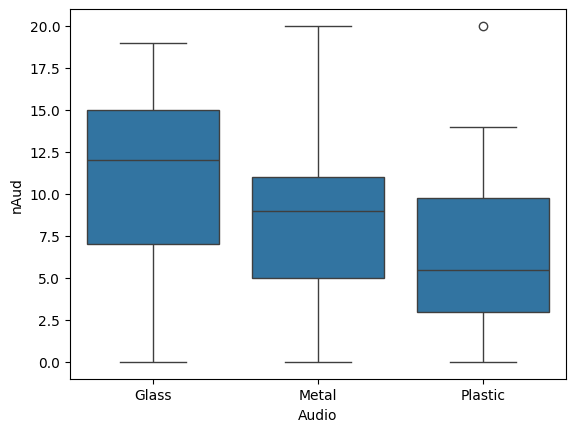

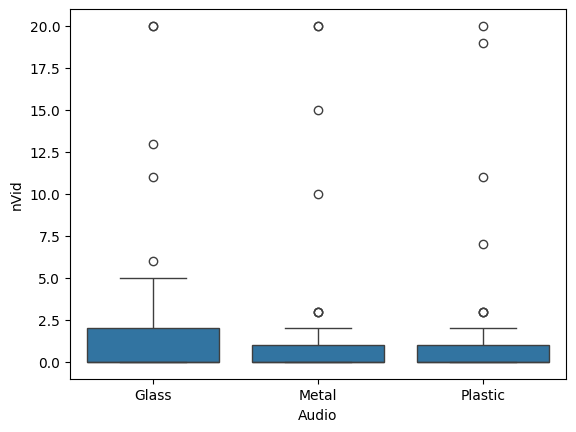

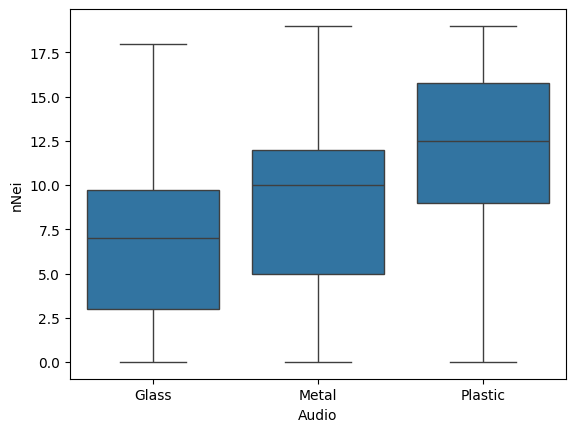

In [ ]:
import seaborn as sns

ax1 = sns.boxplot(x = "Audio", y = "nAud", data = subset_df, legend = False)
plt.savefig('one-way-'+ fixed + '-' + val +'-nAud.png', bbox_inches='tight')
plt.show()

ax2 = sns.boxplot(x = "Audio", y = "nVid", hue = 'Video', data = subset_df, legend = False)
plt.savefig('one-way-'+ fixed + '-' + val +'-nVid.png', bbox_inches='tight')
plt.show()

ax3 = sns.boxplot(x = "Audio", y = "nNei", hue = 'Video', data = subset_df, legend = False)
plt.savefig('one-way-'+ fixed + '-' + val +'-nNei.png', bbox_inches='tight')
plt.show()

# **Repeated measures 2 way ANOVA**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
ls= []
# Perform Repeated Measures ANOVA

print('DV: Frequency of response matched to the Sound')
aovrm = AnovaRM(df_xform, 'nAud', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])

print('DV: Frequency of response matched to the Texture')
aovrm = AnovaRM(df_xform, 'nVid', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])

print('DV: Frequency of response matched to neither')
aovrm = AnovaRM(df_xform, 'nNei', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])

print(ls)

### using partial eta square formula, we get 29.3483*9/29.3483*9+369 = 0.417
### using partial eta square formula, we get 107.2983*9/107.2983*9+369 = 0.417

DV: Frequency of response matched to the Sound
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio       23.5776 3.0000 123.0000 0.0000
Video       23.4943 3.0000 123.0000 0.0000
Audio:Video 29.3483 9.0000 369.0000 0.0000

DV: Frequency of response matched to the Texture
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio       10.2525 3.0000 123.0000 0.0000
Video       64.3511 3.0000 123.0000 0.0000
Audio:Video 49.0719 9.0000 369.0000 0.0000

DV: Frequency of response matched to neither
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio       28.0527 3.0000 123.0000 0.0000
Video       21.6420 3.0000 123.0000 0.0000
Audio:Video 22.3070 9.0000 369.0000 0.0000

[2.0263353357805116e-38, 8.022996897207566e-58, 3.193122952790977e-30]


In [ ]:
import pandas as pd
df_xform1=pd.DataFrame(columns=['Participant_ID', 'Video', 'Audio', '%Aud', '%Vid', '%Nei'])
print(df_xform1)

Target_name = ['Glass', 'Metal', 'Plastic', 'Wood']
Audio_name = ['Glass', 'Metal', 'Plastic', 'Wood']

for m in Target_name:
  for n in Audio_name:
    for sheet_name, df in agent.items():
      count_a = 0
      count_v = 0
      count_n = 0
      for i in df.index:
        if (df['Audio Source'][i] == n) & (df['Target'][i] == m):
          if (df['Matches Audio'][i] == 'Matches') & (df['Matches Target'][i]== 'Matches'):
            count_a = count_a + 1
            count_v = count_v + 1
          elif (df['Matches Audio'][i] == 'Matches'):
            count_a = count_a + 1
          elif (df['Matches Target'][i]== 'Matches'):
            count_v = count_v + 1
          else:
            count_n = count_n + 1

      find_part = sheet_name.split('-')[0]

      for sheet_name2, df2 in self_int.items():
        if (sheet_name2.split('-')[0] == find_part):
          for j in df2.index:
            if (df2['Audio Source'][j] == n) & (df2['Target'][j] == m):
              if (df2['Matches Audio'][j] == 'Matches') & (df2['Matches Target'][j]== 'Matches'):
                count_a = count_a + 1
                count_v = count_v + 1
              elif (df2['Matches Audio'][j] == 'Matches'):
                count_a = count_a + 1
              elif (df2['Matches Target'][j]== 'Matches'):
                count_v = count_v + 1
              else:
                count_n = count_n + 1

      #df_xform1.loc[len(df_xform1.index)] = [find_part, m, n, count_a*5, count_v*5, count_n*5]
      df_xform1.loc[len(df_xform1.index)] = [find_part, m, n, count_a, count_v, count_n]

print(df_xform1)
# Filter rows to show only mismatch conditions
fil_df1 = df_xform1[df_xform1['Video'] != df_xform1['Audio']]
fil_df1.reset_index(drop=True, inplace=True)

##should i convert to % here? - Yes ANOVA dependent varaible needs to be a ratio/continuous - casued no difference in results here

df_xform1.head(50)

Empty DataFrame
Columns: [Participant_ID, Video, Audio, %Aud, %Vid, %Nei]
Index: []
    Participant_ID  Video  Audio  %Aud  %Vid  %Nei
0               P1  Glass  Glass    13    13     7
1               P2  Glass  Glass    12    12     8
2               P4  Glass  Glass    18    18     2
3               P5  Glass  Glass    19    19     1
4               P6  Glass  Glass    12    12     8
..             ...    ...    ...   ...   ...   ...
667            P48   Wood   Wood    19    19     1
668            P49   Wood   Wood    20    20     0
669            P50   Wood   Wood    20    20     0
670            P51   Wood   Wood    19    19     1
671            P53   Wood   Wood    20    20     0

[672 rows x 6 columns]


,Participant_ID,Video,Audio,%Aud,%Vid,%Nei
0,P1,Glass,Glass,13,13,7
1,P2,Glass,Glass,12,12,8
2,P4,Glass,Glass,18,18,2
3,P5,Glass,Glass,19,19,1
4,P6,Glass,Glass,12,12,8
5,P7,Glass,Glass,15,15,5
6,P8,Glass,Glass,14,14,6
7,P9,Glass,Glass,20,20,0
8,P10,Glass,Glass,16,16,4
9,P11,Glass,Glass,7,7,13


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
ls= []
# Perform Repeated Measures ANOVA

print('DV: Percentage of response matched to the Sound')
aovrm = AnovaRM(df_xform1, '%Aud', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])

print('DV: Percentage of response matched to the Texture')
aovrm = AnovaRM(df_xform1, '%Vid', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])

print('DV: Percentage of response matched to neither')
aovrm = AnovaRM(df_xform1, '%Nei', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])

print(ls)

### using partial eta square formula, we get 29.3483*9/29.3483*9+369 = 0.417
### using partial eta square formula, we get 107.2983*9/107.2983*9+369 = 0.722

DV: Percentage of response matched to the Sound
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio       23.5776 3.0000 123.0000 0.0000
Video       23.4943 3.0000 123.0000 0.0000
Audio:Video 29.3483 9.0000 369.0000 0.0000

DV: Percentage of response matched to the Texture
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio        2.2793 3.0000 123.0000 0.0828
Video       26.6697 3.0000 123.0000 0.0000
Audio:Video 63.4160 9.0000 369.0000 0.0000

DV: Percentage of response matched to neither
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio       28.0527 3.0000 123.0000 0.0000
Video       21.6420 3.0000 123.0000 0.0000
Audio:Video 22.3070 9.0000 369.0000 0.0000

[2.0263353357805116e-38, 1.687081479428576e-69, 3.193122952790977e-30]


In [ ]:
#Sphericity
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 7.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pingouin as pg
pg.sphericity(df_xform1, dv='%Aud', subject='Participant_ID', within='Audio')
pg.sphericity(df_xform1, dv='%Aud', subject='Participant_ID', within='Video')

SpherResults(spher=False, W=0.36289968970198605, chi2=40.26358923152021, dof=5, pval=1.3412072972884542e-07)

# **GREENHOUSE GEISSER CORRECTIONS for 2-way omnibusses**

In [ ]:
#trying the epsilon correction for when sph is not met - for DV = %matched_to_audio
import numpy as np
import pandas as pd

# Pivot to wide format (Subject x FactorA_FactorB combinations)
df_xform1['Condition'] = df_xform1['Video'] + '_' + df_xform1['Audio']
wide_data_a = df_xform1.pivot(index='Participant_ID', columns='Condition', values='%Aud')
#wide_data_v = df_xform1.pivot(index='Participant_ID', columns='Condition', values='%Vid')
#wide_data_n = df_xform1.pivot(index='Participant_ID', columns='Condition', values='%Nei')
wide_data_a = wide_data_a.dropna()

# Step 1: Compute covariance matrix for each effect
cov_matrix = np.cov(wide_data_a.T)

# Helper function to compute epsilon
def compute_epsilon(cov_matrix):
    k = cov_matrix.shape[0]  # Number of levels
    trace_cov = np.trace(cov_matrix)
    trace_cov_squared = np.trace(np.dot(cov_matrix, cov_matrix))
    epsilon = (trace_cov ** 2) / (trace_cov_squared * (k - 1))
    return epsilon

# Step 2: Split covariance matrices (main effects and interaction)
# Factor A (marginalize over Factor B)
cov_matrix_vid = np.cov(wide_data_a.T.groupby(lambda x: x.split('_')[0]).mean())

# Factor B (marginalize over Factor A)
cov_matrix_aud = np.cov(wide_data_a.T.groupby(lambda x: x.split('_')[1]).mean())

# Interaction (original matrix already accounts for interaction)
cov_matrix_interaction = cov_matrix

# Step 3: Calculate epsilon for each effect
epsilon_vid = compute_epsilon(cov_matrix_vid)
epsilon_aud = compute_epsilon(cov_matrix_aud)
epsilon_interaction = compute_epsilon(cov_matrix_interaction)

print("Greenhouse-Geisser epsilon for Factor Video:", epsilon_vid)
print("Greenhouse-Geisser epsilon for Factor Audio:", epsilon_aud)
print("Greenhouse-Geisser epsilon for Interaction:", epsilon_interaction)

epsilon_dv_aud = []
epsilon_dv_aud.append(epsilon_aud)
epsilon_dv_aud.append(epsilon_vid)
epsilon_dv_aud.append(epsilon_interaction)

Greenhouse-Geisser epsilon for Factor Video: 0.5521080439323391
Greenhouse-Geisser epsilon for Factor Audio: 0.8540741062439473
Greenhouse-Geisser epsilon for Interaction: 0.3175731720728541


In [ ]:
import scipy.stats as stats
'''
F_value = 29.3483  # F-value from the ANOVA table
df_num = 9      # Numerator degrees of freedom
df_den = 369     # Denominator degrees of freedom

# Compute F-CDF
#F_cdf = stats.f.cdf(F_value, df_num, df_den)
#print("F_cdf: ")
#print(F_cdf)
'''
df_num_ls = []
df_den_ls = []
p_val_ls = []

#--------for aud factor-----------
df_num = 3  # Original numerator degrees of freedom
df_den = 123  # Original denominator degrees of freedom
epsilon = 0.8540741062439473  # Greenhouse-Geisser epsilon
F_value = 23.5776  # Calculated F-value

# Step 1: Adjust degrees of freedom
df_num_adj = epsilon * df_num
df_den_adj = epsilon * df_den

# Step 2: Recalculate p-value
p_value_adj = 1 - stats.f.cdf(F_value, df_num_adj, df_den_adj)
print("p_value_adj for audio factor: ")
print(p_value_adj)

#add to list
df_num_ls.append(df_num_adj)
df_den_ls.append(df_den_adj)
p_val_ls.append(p_value_adj)

#-------for vid factor---------
df_num = 3  # Original numerator degrees of freedom
df_den = 123  # Original denominator degrees of freedom
epsilon = 0.5521080439323391  # Greenhouse-Geisser epsilon
F_value = 23.4943  # Calculated F-value

# Step 1: Adjust degrees of freedom
df_num_adj = epsilon * df_num
df_den_adj = epsilon * df_den

# Step 2: Recalculate p-value
p_value_adj = 1 - stats.f.cdf(F_value, df_num_adj, df_den_adj)
print("p_value_adj for video factor: ")
print(p_value_adj)

df_num_ls.append(df_num_adj)
df_den_ls.append(df_den_adj)
p_val_ls.append(p_value_adj)

#--------for interaction--------
df_num = 9  # Original numerator degrees of freedom
df_den = 369  # Original denominator degrees of freedom
epsilon = 0.3175731720728541  # Greenhouse-Geisser epsilon
F_value = 29.3483  # Calculated (unchanged) F-value

# Step 1: Adjust degrees of freedom
df_num_adj = epsilon * df_num
df_den_adj = epsilon * df_den

# Step 2: Recalculate p-value
p_value_adj = 1 - stats.f.cdf(F_value, df_num_adj, df_den_adj)
print("Adjusted df_num:")
print(df_num_adj)
print("Adjusted df_den:")
print(df_den_adj)
print("p_value_adj for interaction: ")
print(p_value_adj)

df_num_ls.append(df_num_adj)
df_den_ls.append(df_den_adj)
p_val_ls.append(p_value_adj)


p_value_adj for audio factor: 
1.1175416148034856e-10
p_value_adj for video factor: 
1.1832153268276357e-07
Adjusted df_num:
2.858158548655687
Adjusted df_den:
117.18450049488317
p_value_adj for interaction: 
8.248957072964913e-14


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
ls= []
# Perform Repeated Measures ANOVA

print('DV: Percentage of response matched to the Sound')
aovrm = AnovaRM(df_xform1, '%Aud', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])
res.anova_table['E_gg'] = epsilon_dv_aud
res.anova_table['Adj DF_Num'] = df_num_ls
res.anova_table['Adj DF_Den'] = df_den_ls
res.anova_table['Adj p-value'] = p_val_ls
print('DV: Percentage of responses matched to the Sound')
res.anova_table

DV: Percentage of response matched to the Sound
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio       23.5776 3.0000 123.0000 0.0000
Video       23.4943 3.0000 123.0000 0.0000
Audio:Video 29.3483 9.0000 369.0000 0.0000

DV: Percentage of responses matched to the Sound


,F Value,Num DF,Den DF,Pr > F,E_gg,Adj DF_Num,Adj DF_Den,Adj p-value
Audio,23.577573,3.0,123.0,4.007173e-12,0.854074,2.562222,105.051115,1.117542e-10
Video,23.494332,3.0,123.0,4.333325e-12,0.552108,1.656324,67.909289,1.183215e-07
Audio:Video,29.348327,9.0,369.0,2.026335e-38,0.317573,2.858159,117.184500,8.248957e-14


In [ ]:
#trying the epsilon correction for when sph is not met - for DV = %matched_to_video
import numpy as np
import pandas as pd

# Pivot to wide format (Subject x FactorA_FactorB combinations)
df_xform1['Condition'] = df_xform1['Video'] + '_' + df_xform1['Audio']
#wide_data_a = df_xform1.pivot(index='Participant_ID', columns='Condition', values='%Aud')
wide_data_v = df_xform1.pivot(index='Participant_ID', columns='Condition', values='%Vid')
#wide_data_n = df_xform1.pivot(index='Participant_ID', columns='Condition', values='%Nei')
wide_data_v = wide_data_v.dropna()

# Step 1: Compute covariance matrix for each effect
cov_matrix = np.cov(wide_data_v.T)

# Helper function to compute epsilon
def compute_epsilon(cov_matrix):
    k = cov_matrix.shape[0]  # Number of levels
    trace_cov = np.trace(cov_matrix)
    trace_cov_squared = np.trace(np.dot(cov_matrix, cov_matrix))
    epsilon = (trace_cov ** 2) / (trace_cov_squared * (k - 1))
    return epsilon

# Step 2: Split covariance matrices (main effects and interaction)
# Factor A (marginalize over Factor B)
cov_matrix_vid = np.cov(wide_data_v.T.groupby(lambda x: x.split('_')[0]).mean())

# Factor B (marginalize over Factor A)
cov_matrix_aud = np.cov(wide_data_v.T.groupby(lambda x: x.split('_')[1]).mean())

# Interaction (original matrix already accounts for interaction)
cov_matrix_interaction = cov_matrix

# Step 3: Calculate epsilon for each effect
epsilon_vid = compute_epsilon(cov_matrix_vid)
epsilon_aud = compute_epsilon(cov_matrix_aud)
epsilon_interaction = compute_epsilon(cov_matrix_interaction)

print("Greenhouse-Geisser epsilon for Factor Video:", epsilon_vid)
print("Greenhouse-Geisser epsilon for Factor Audio:", epsilon_aud)
print("Greenhouse-Geisser epsilon for Interaction:", epsilon_interaction)

epsilon_dv_vid = []
epsilon_dv_vid.append(epsilon_aud)
epsilon_dv_vid.append(epsilon_vid)
epsilon_dv_vid.append(epsilon_interaction)

Greenhouse-Geisser epsilon for Factor Video: 0.46385717525180314
Greenhouse-Geisser epsilon for Factor Audio: 0.39799711290049744
Greenhouse-Geisser epsilon for Interaction: 0.21551285653058122


In [ ]:
import scipy.stats as stats

df_num = 9  # Original numerator degrees of freedom
df_den = 369  # Original denominator degrees of freedom
epsilon = 0.21551285653058122  # Greenhouse-Geisser epsilon
F_value = 63.4160  # Calculated (unchanged) F-value

# Step 1: Adjust degrees of freedom
df_num_adj = epsilon * df_num
df_den_adj = epsilon * df_den

# Step 2: Recalculate p-value
p_value_adj = 1 - stats.f.cdf(F_value, df_num_adj, df_den_adj)
print("Adjusted df_num:")
print(df_num_adj)
print("Adjusted df_den:")
print(df_den_adj)
print("p_value_adj for interaction: ")
print(p_value_adj)

Adjusted df_num:
1.939615708775231
Adjusted df_den:
79.52424405978446
p_value_adj for interaction: 
1.1102230246251565e-16


In [ ]:
df_num_ls = []
df_den_ls = []
p_val_ls = []

#--------for aud factor-----------
df_num = 3  # Original numerator degrees of freedom
df_den = 123  # Original denominator degrees of freedom
epsilon = 0.39799711290049744  # Greenhouse-Geisser epsilon
F_value = 2.2793  # Calculated F-value

# Step 1: Adjust degrees of freedom
df_num_adj = epsilon * df_num
df_den_adj = epsilon * df_den

# Step 2: Recalculate p-value
p_value_adj = 1 - stats.f.cdf(F_value, df_num_adj, df_den_adj)
print("p_value_adj for audio factor: ")
print(p_value_adj)

#add to list
df_num_ls.append(df_num_adj)
df_den_ls.append(df_den_adj)
p_val_ls.append(p_value_adj)

#-------for vid factor---------
df_num = 3  # Original numerator degrees of freedom
df_den = 123  # Original denominator degrees of freedom
epsilon = 0.46385717525180314  # Greenhouse-Geisser epsilon
F_value = 26.6697  # Calculated F-value

# Step 1: Adjust degrees of freedom
df_num_adj = epsilon * df_num
df_den_adj = epsilon * df_den

# Step 2: Recalculate p-value
p_value_adj = 1 - stats.f.cdf(F_value, df_num_adj, df_den_adj)
print("p_value_adj for video factor: ")
print(p_value_adj)

df_num_ls.append(df_num_adj)
df_den_ls.append(df_den_adj)
p_val_ls.append(p_value_adj)

#--------for interaction--------
df_num = 9  # Original numerator degrees of freedom
df_den = 369  # Original denominator degrees of freedom
epsilon = 0.21551285653058122  # Greenhouse-Geisser epsilon
F_value = 63.4160  # Calculated (unchanged) F-value

# Step 1: Adjust degrees of freedom
df_num_adj = epsilon * df_num
df_den_adj = epsilon * df_den

# Step 2: Recalculate p-value
p_value_adj = 1 - stats.f.cdf(F_value, df_num_adj, df_den_adj)
print("Adjusted df_num:")
print(df_num_adj)
print("Adjusted df_den:")
print(df_den_adj)
print("p_value_adj for interaction: ")
print(p_value_adj)

df_num_ls.append(df_num_adj)
df_den_ls.append(df_den_adj)
p_val_ls.append(p_value_adj)

p_value_adj for audio factor: 
0.13335034490959186
p_value_adj for video factor: 
2.2326636828218227e-07
Adjusted df_num:
1.939615708775231
Adjusted df_den:
79.52424405978446
p_value_adj for interaction: 
1.1102230246251565e-16


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
ls= []
# Perform Repeated Measures ANOVA
print('DV: Percentage of response matched to the Texture')
aovrm = AnovaRM(df_xform1, '%Vid', 'Participant_ID', within=['Audio', 'Video'])
res = aovrm.fit()
print(res.summary())
ls.append(res.anova_table["Pr > F"]['Audio:Video'])

res.anova_table['E_gg'] = epsilon_dv_vid
res.anova_table['Adj DF_Num'] = df_num_ls
res.anova_table['Adj DF_Den'] = df_den_ls
res.anova_table['Adj p-value'] = p_val_ls
print('DV: Percentage of responses matched to the visual texture')
res.anova_table

DV: Percentage of response matched to the Texture
                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
Audio        2.2793 3.0000 123.0000 0.0828
Video       26.6697 3.0000 123.0000 0.0000
Audio:Video 63.4160 9.0000 369.0000 0.0000

DV: Percentage of responses matched to the visual texture


,F Value,Num DF,Den DF,Pr > F,E_gg,Adj DF_Num,Adj DF_Den,Adj p-value
Audio,2.279256,3.0,123.0,8.277998e-02,0.397997,1.193991,48.953645,1.333503e-01
Video,26.669666,3.0,123.0,2.341851e-13,0.463857,1.391572,57.054433,2.232664e-07
Audio:Video,63.416045,9.0,369.0,1.687081e-69,0.215513,1.939616,79.524244,1.110223e-16


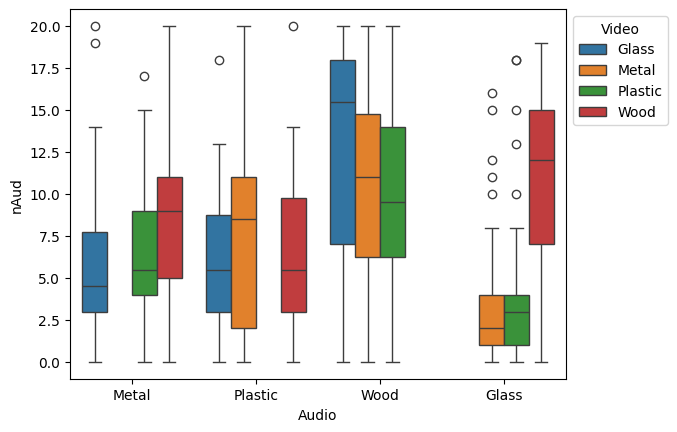

In [ ]:
ax = sns.boxplot(x = "Audio", y = "nAud", hue = 'Video', data = fil_df)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('4x4-nAud.png', bbox_inches='tight')

# **Tukey tests**

In [ ]:
#---p value correction----

In [ ]:
from statsmodels.sandbox.stats.multicomp import multipletests
p_adjusted = multipletests(ls, alpha=0.05, method='bonferroni')
print(p_adjusted)

(array([ True]), array([1.68708148e-69]), 0.050000000000000044, 0.05)


In [ ]:
#---t test/ tuckey hsd test----

In [ ]:
import pandas as pd
df_xform3=pd.DataFrame(columns=['Participant_ID', 'Video', 'Audio', '%Audio', '%Video', '%Neither'])
print(df_xform3)

'''
#1
Target_name = ['Glass']
Audio_name = ['Metal', 'Plastic', 'Wood']

#2
Target_name = ['Metal']
Audio_name = ['Glass', 'Plastic', 'Wood']

#3
Target_name = ['Plastic']
Audio_name = ['Glass', 'Metal', 'Wood']

#4
Target_name = ['Wood']
Audio_name = ['Glass', 'Metal', 'Plastic']

#5
Audio_name = ['Glass']
Target_name = ['Metal', 'Plastic', 'Wood']

#6
Audio_name = ['Metal']
Target_name = ['Glass', 'Plastic', 'Wood']

#7
Audio_name = ['Plastic']
Target_name = ['Glass', 'Metal', 'Wood']

#8
Audio_name = ['Wood']
Target_name = ['Glass', 'Metal', 'Plastic']

'''
#4
Target_name = ['Wood']
Audio_name = ['Glass', 'Metal', 'Plastic']

for m in Target_name:
  for n in Audio_name:
    for sheet_name, df in agent.items():
      count_a = 0
      count_v = 0
      count_n = 0
      for i in df.index:
        if (df['Audio Source'][i] == n) & (df['Target'][i] == m):
          if (df['Matches Audio'][i] == 'Matches'):
            count_a = count_a + 1
          elif (df['Matches Target'][i]== 'Matches'):
            count_v = count_v + 1
          else:
            count_n = count_n + 1

      find_part = sheet_name.split('-')[0]

      for sheet_name2, df2 in self_int.items():
          if (sheet_name2.split('-')[0] == find_part):
            for j in df2.index:
              if (df2['Audio Source'][j] == n) & (df2['Target'][j] == m):
                if (df2['Matches Audio'][j] == 'Matches'):
                  count_a = count_a + 1
                elif (df2['Matches Target'][j]== 'Matches'):
                  count_v = count_v + 1
                else:
                  count_n = count_n + 1

      df_xform3.loc[len(df_xform3.index)] = [find_part, m, n, count_a*5, count_v*5, count_n*5]
print(df_xform3)


Empty DataFrame
Columns: [Participant_ID, Video, Audio, %Audio, %Video, %Neither]
Index: []
    Participant_ID Video    Audio  %Audio  %Video  %Neither
0               P1  Wood    Glass      75       0        25
1               P2  Wood    Glass      25      10        65
2               P4  Wood    Glass      90       0        10
3               P5  Wood    Glass      95       0         5
4               P6  Wood    Glass      65       0        35
..             ...   ...      ...     ...     ...       ...
121            P48  Wood  Plastic      45       0        55
122            P49  Wood  Plastic      65       0        35
123            P50  Wood  Plastic      25      15        60
124            P51  Wood  Plastic      10      15        75
125            P53  Wood  Plastic      25       0        75

[126 rows x 6 columns]


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.base.model import Model

tukey_oneway = pairwise_tukeyhsd(endog = df_xform3["%Audio"], groups = df_xform3["Audio"])
#tukey_oneway = pairwise_tukeyhsd(endog = df_xform3["%Video"], groups = df_xform3["Audio"])
#tukey_oneway = pairwise_tukeyhsd(endog = df_xform3["%Neither"], groups = df_xform3["Audio"])

'''
#tukey_oneway = pairwise_tukeyhsd(endog = df_xform3["nAud"], groups = df_xform3["Video"])
#tukey_oneway = pairwise_tukeyhsd(endog = df_xform3["nVid"], groups = df_xform3["Video"])
tukey_oneway = pairwise_tukeyhsd(endog = df_xform3["nNei"], groups = df_xform3["Video"])
'''

# Display the results
tukey_oneway.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Glass,Metal,-9.2857,0.2351,-22.7647,4.1933,False
Glass,Plastic,-20.9524,0.001,-34.4314,-7.4734,True
Metal,Plastic,-11.6667,0.104,-25.1456,1.8123,False


# **Self-vs-agent interaction RM ANOVA**

In [ ]:
#Self vs agent RM anova
#making table first
import pandas as pd
df_inter=pd.DataFrame(columns=['Participant_ID', 'Interaction', 'nAud', 'nVid', 'nNei'])
print(df_inter)

for sheet_name, df in agent.items():
  count_a = 0
  count_v = 0
  count_n = 0
  for i in df.index:
    if (df['Audio Source'][i] != df['Target'][i]):
      if (df['Matches Audio'][i] == 'Matches'):
        count_a = count_a + 1
      elif (df['Matches Target'][i]== 'Matches'):
        count_v = count_v + 1
      else:
         count_n = count_n + 1
  find_part = sheet_name.split('-')[0]
  df_inter.loc[len(df_inter.index)] = [find_part, "Agent Interaction", count_a, count_v, count_n]

for sheet_name, df in self_int.items():
  count_a = 0
  count_v = 0
  count_n = 0
  for i in df.index:
    if (df['Audio Source'][i] != df['Target'][i]):
      if (df['Matches Audio'][i] == 'Matches'):
        count_a = count_a + 1
      elif (df['Matches Target'][i]== 'Matches'):
        count_v = count_v + 1
      else:
         count_n = count_n + 1
  find_part = sheet_name.split('-')[0]
  df_inter.loc[len(df_inter.index)] = [find_part, "Self-Interaction", count_a, count_v, count_n]

print(df_inter)


Empty DataFrame
Columns: [Participant_ID, Interaction, nAud, nVid, nNei]
Index: []
   Participant_ID        Interaction  nAud  nVid  nNei
0              P1  Agent Interaction    47    22    51
1              P2  Agent Interaction    32    33    55
2              P4  Agent Interaction    43    39    38
3              P5  Agent Interaction    66    13    41
4              P6  Agent Interaction    39    34    47
..            ...                ...   ...   ...   ...
79            P48   Self-Interaction    70    21    29
80            P49   Self-Interaction    65    28    27
81            P50   Self-Interaction    43    23    54
82            P51   Self-Interaction    30    39    51
83            P53   Self-Interaction    62    16    42

[84 rows x 5 columns]


In [ ]:
self_group = df_inter[df_inter['Interaction'] == 'Agent Interaction']['nAud']
agent_group = df_inter[df_inter['Interaction'] == 'Self-Interaction']['nAud']

In [ ]:
#t test instead of anova first
import numpy as np
from scipy.stats import ttest_rel

# Perform a paired t-test
t_stat, p_value = ttest_rel(self_group, agent_group)

# Display results
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: Significant difference between treatments.")
else:
    print("Fail to reject the null hypothesis: No significant difference between treatments.")

T-statistic: 0.039
P-value: 0.969
Fail to reject the null hypothesis: No significant difference between treatments.


When checking the responses matched to the Sound
                  Anova
            F Value Num DF  Den DF Pr > F
-----------------------------------------
Interaction  0.0015 1.0000 41.0000 0.9689

When checking the responses matched to the Appearance
                  Anova
            F Value Num DF  Den DF Pr > F
-----------------------------------------
Interaction  0.2007 1.0000 41.0000 0.6565

When checking the responses matched to neither
                  Anova
            F Value Num DF  Den DF Pr > F
-----------------------------------------
Interaction  0.2017 1.0000 41.0000 0.6557



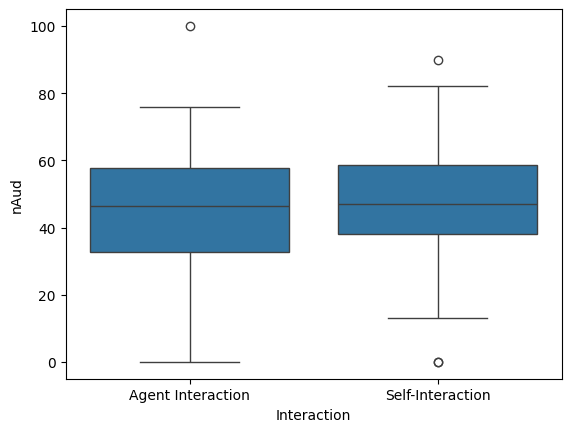

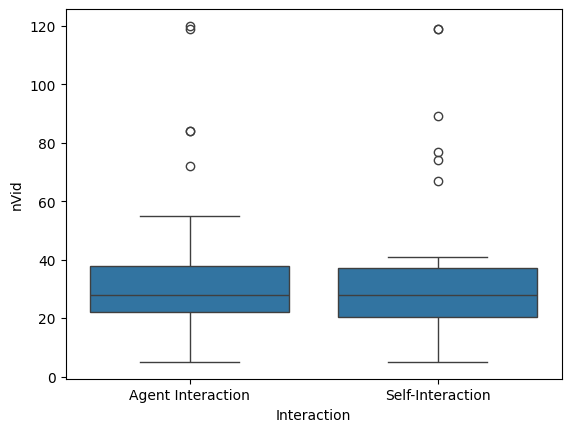

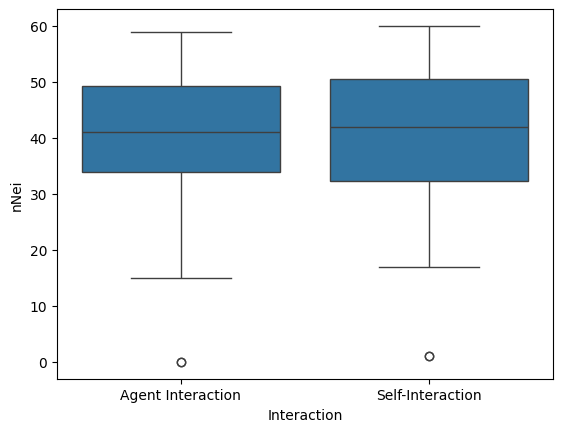

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import seaborn as sns

#anovas

print('When checking the responses matched to the Sound')
aovrm = AnovaRM(df_inter, 'nAud', 'Participant_ID', within=['Interaction'])
res = aovrm.fit()
print(res.summary())
print('When checking the responses matched to the Appearance')
aovrm = AnovaRM(df_inter, 'nVid', 'Participant_ID', within=['Interaction'])
res = aovrm.fit()
print(res.summary())
print('When checking the responses matched to neither')
aovrm = AnovaRM(df_inter, 'nNei', 'Participant_ID', within=['Interaction'])
res = aovrm.fit()
print(res.summary())

ax1 = sns.boxplot(x = "Interaction", y = "nAud", data = df_inter, legend = False)
#plt.savefig('one-way-'+ fixed + '-' + val +'-nAud.png', bbox_inches='tight')
plt.show()

ax2 = sns.boxplot(x = "Interaction", y = "nVid",  data = df_inter, legend = False)
#plt.savefig('one-way-'+ fixed + '-' + val +'-nVid.png', bbox_inches='tight')
plt.show()

ax3 = sns.boxplot(x = "Interaction", y = "nNei",  data = df_inter, legend = False)
#plt.savefig('one-way-'+ fixed + '-' + val +'-nNei.png', bbox_inches='tight')
plt.show()

In [ ]:
#what if i run the anova for all conditions and not just mismatch
import pandas as pd
df_inter2=pd.DataFrame(columns=['Participant_ID', 'Interaction', '%Aud', '%Vid', '%Nei'])
print(df_inter2)

for sheet_name, df in agent.items():
  count_a = 0
  count_v = 0
  count_n = 0
  for i in df.index:
    if (df['Matches Audio'][i] == 'Matches') & (df['Matches Target'][i]== 'Matches'):
      count_a = count_a + 1
      count_v = count_v + 1
    elif (df['Matches Audio'][i] == 'Matches'):
      count_a = count_a + 1
    elif (df['Matches Target'][i]== 'Matches'):
      count_v = count_v + 1
    else:
      count_n = count_n + 1
  find_part = sheet_name.split('-')[0]
  df_inter2.loc[len(df_inter2.index)] = [find_part, "Agent Interaction", count_a*0.625, count_v*0.625, count_n*0.625]

for sheet_name, df in self_int.items():
  count_a = 0
  count_v = 0
  count_n = 0
  for i in df.index:
    if (df['Matches Audio'][i] == 'Matches') & (df['Matches Target'][i]== 'Matches'):
      count_a = count_a + 1
      count_v = count_v + 1
    elif (df['Matches Audio'][i] == 'Matches'):
      count_a = count_a + 1
    elif (df['Matches Target'][i]== 'Matches'):
      count_v = count_v + 1
    else:
      count_n = count_n + 1
  find_part = sheet_name.split('-')[0]
  df_inter2.loc[len(df_inter2.index)] = [find_part, "Self-Interaction", count_a*0.625, count_v*0.625, count_n*0.625]

print(df_inter2)



Empty DataFrame
Columns: [Participant_ID, Interaction, %Aud, %Vid, %Nei]
Index: []
   Participant_ID        Interaction    %Aud    %Vid    %Nei
0              P1  Agent Interaction  44.375  28.750  41.875
1              P2  Agent Interaction  30.625  31.250  48.750
2              P4  Agent Interaction  40.625  38.125  35.000
3              P5  Agent Interaction  61.875  28.750  30.000
4              P6  Agent Interaction  41.875  38.750  36.875
..            ...                ...     ...     ...     ...
79            P48   Self-Interaction  60.625  30.000  26.250
80            P49   Self-Interaction  61.250  38.125  21.250
81            P50   Self-Interaction  37.500  25.000  48.125
82            P51   Self-Interaction  41.250  46.875  34.375
83            P53   Self-Interaction  53.750  25.000  36.250

[84 rows x 5 columns]


In [ ]:
agent_group = df_inter2[df_inter2['Interaction'] == 'Agent Interaction']['%Nei']
self_group = df_inter2[df_inter2['Interaction'] == 'Self-Interaction']['%Nei']

#t test instead of anova first
import numpy as np
from scipy.stats import ttest_rel

# Perform a paired t-test
t_stat, p_value = ttest_rel(agent_group, self_group)

# Display results
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: Significant difference between treatments.")
else:
    print("Fail to reject the null hypothesis: No significant difference between treatments.")

T-statistic: 0.187
P-value: 0.853
Fail to reject the null hypothesis: No significant difference between treatments.


When checking the responses matched to the Sound
                  Anova
            F Value Num DF  Den DF Pr > F
-----------------------------------------
Interaction  0.3309 1.0000 41.0000 0.5683

When checking the responses matched to the Appearance
                  Anova
            F Value Num DF  Den DF Pr > F
-----------------------------------------
Interaction  0.0529 1.0000 41.0000 0.8192

When checking the responses matched to neither
                  Anova
            F Value Num DF  Den DF Pr > F
-----------------------------------------
Interaction  0.0349 1.0000 41.0000 0.8527



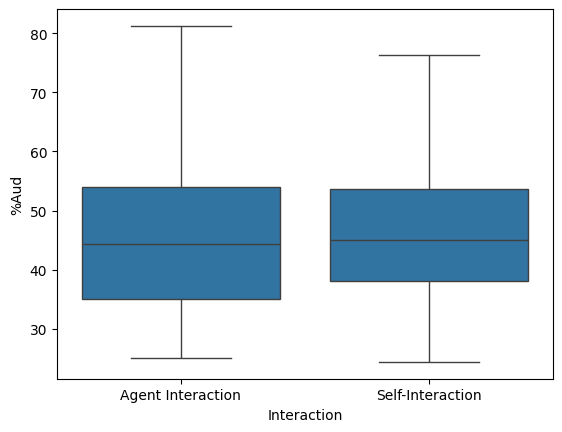

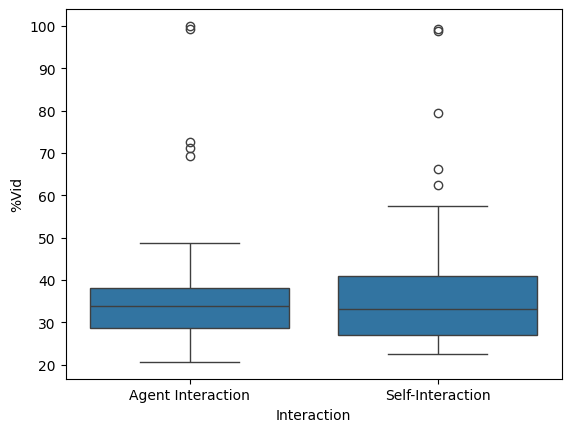

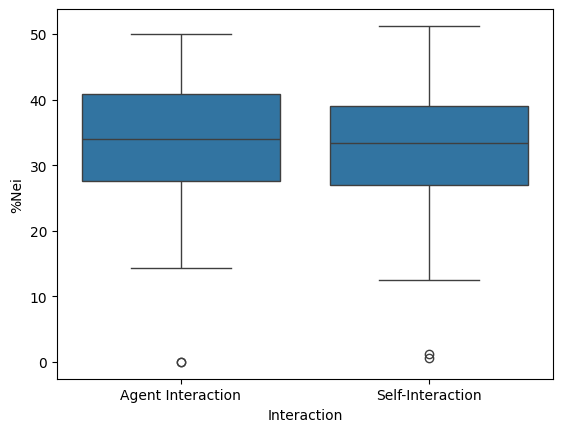

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import seaborn as sns

#anovas

print('When checking the responses matched to the Sound')
aovrm = AnovaRM(data = df_inter2, depvar = '%Aud', subject = 'Participant_ID', within=['Interaction'])
res = aovrm.fit()
print(res.summary())
print('When checking the responses matched to the Appearance')
aovrm = AnovaRM(data = df_inter2, depvar = '%Vid', subject = 'Participant_ID', within=['Interaction'])
res = aovrm.fit()
print(res.summary())
print('When checking the responses matched to neither')
aovrm = AnovaRM(data = df_inter2, depvar = '%Nei', subject = 'Participant_ID', within=['Interaction'])
res = aovrm.fit()
print(res.summary())

ax1 = sns.boxplot(x = "Interaction", y = "%Aud", data = df_inter2, legend = False)
#plt.savefig('one-way-'+ fixed + '-' + val +'-nAud.png', bbox_inches='tight')
plt.show()

ax2 = sns.boxplot(x = "Interaction", y = "%Vid",  data = df_inter2, legend = False)
#plt.savefig('one-way-'+ fixed + '-' + val +'-nVid.png', bbox_inches='tight')
plt.show()

ax3 = sns.boxplot(x = "Interaction", y = "%Nei",  data = df_inter2, legend = False)
#plt.savefig('one-way-'+ fixed + '-' + val +'-nNei.png', bbox_inches='tight')
plt.show()

# **POST-HOCS types and analysis**

In [ ]:
!pip install scikit_posthocs

In [ ]:
#mcg specific conditions testing to see if statistically significant graphs
import pandas as pd
import pandas as pd
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.base.model import Model

df_spec=pd.DataFrame(columns=['Participant_ID', 'Condition', 'Option', 'Freq'])
#print(df_spec)

#Target_name
m = 'Metal'
#Audio_name
n = 'Wood'

for sheet_name, df in agent.items():
  count_g = 0
  count_m = 0
  count_p = 0
  count_w = 0
  find_part = sheet_name.split('-')[0]
  for i in df.index:
    if (df['Audio Source'][i] == n) & (df['Target'][i] == m):
      if (df['Option'][i] == 'Glass'):
        count_g = count_g + 1
      elif (df['Option'][i] == 'Metal'):
        count_m = count_m + 1
      elif (df['Option'][i] == 'Plastic'):
        count_p = count_p + 1
      elif (df['Option'][i] == 'Wood'):
        count_w = count_w + 1
        #print("Agent "+ find_part + " " + str(count_w))

  for sheet_name2, df2 in self_int.items():
    if (sheet_name2.split('-')[0] == find_part):
      for j in df2.index:
        if (df2['Audio Source'][j] == n) & (df2['Target'][j] == m):
          if (df2['Option'][j] == 'Glass'):
            count_g = count_g + 1
          elif (df2['Option'][j] == 'Metal'):
            count_m = count_m + 1
          elif (df2['Option'][j] == 'Plastic'):
            count_p = count_p + 1
          elif(df2['Option'][j] == 'Wood'):
            count_w = count_w + 1
            #print("Self "+ find_part + " " + str(count_w))

  df_spec.loc[len(df_spec.index)] = [find_part, m+ " Texture & "+ n + " sound", 'Glass', count_g]
  df_spec.loc[len(df_spec.index)] = [find_part, m+ " Texture & "+ n + " sound", 'Metal', count_m]
  df_spec.loc[len(df_spec.index)] = [find_part, m+ " Texture & "+ n + " sound", 'Plastic', count_p]
  df_spec.loc[len(df_spec.index)] = [find_part, m+ " Texture & "+ n + " sound", 'Wood', count_w]
#print(df_spec)

#tuckey output
print("For "+ m +" Texture and " + n+ " Audio: ")
tukey_oneway = pairwise_tukeyhsd(endog = df_spec["Freq"], groups = df_spec["Option"])
tukey_oneway.summary()


For Metal Texture and Wood Audio: 


group1,group2,meandiff,p-adj,lower,upper,reject
Glass,Metal,4.5238,0.0,1.9817,7.0659,True
Glass,Plastic,2.5476,0.0493,0.0055,5.0898,True
Glass,Wood,9.7857,0.0,7.2436,12.3279,True
Metal,Plastic,-1.9762,0.1857,-4.5183,0.5659,False
Metal,Wood,5.2619,0.0,2.7198,7.804,True
Plastic,Wood,7.2381,0.0,4.696,9.7802,True


In [ ]:

#Dunn's method
data = [df_spec[df_spec['Option'] == 'Glass']['Freq'],
        df_spec[df_spec['Option'] == 'Metal']['Freq'],
        df_spec[df_spec['Option'] == 'Plastic']['Freq'],
        df_spec[df_spec['Option'] == 'Wood']['Freq'],]
p_values = sp.posthoc_dunn(data, p_adjust='bonferroni')
print(p_values)
print(p_values <0.05)

              1         2         3             4
1  1.000000e+00  0.000081  0.006046  1.152597e-14
2  8.109033e-05  1.000000  1.000000  1.948243e-03
3  6.046023e-03  1.000000  1.000000  1.916096e-05
4  1.152597e-14  0.001948  0.000019  1.000000e+00
       1      2      3      4
1  False   True   True   True
2   True  False  False   True
3   True  False  False   True
4   True   True   True  False


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.base.model import Model

tukey_oneway = pairwise_tukeyhsd(endog = df_spec["Freq"], groups = df_spec["Option"])

# Display the results
tukey_oneway.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Glass,Metal,4.5238,0.0,1.9817,7.0659,True
Glass,Plastic,2.5476,0.0493,0.0055,5.0898,True
Glass,Wood,9.7857,0.0,7.2436,12.3279,True
Metal,Plastic,-1.9762,0.1857,-4.5183,0.5659,False
Metal,Wood,5.2619,0.0,2.7198,7.804,True
Plastic,Wood,7.2381,0.0,4.696,9.7802,True


In [ ]:
# Importing necessary packages and modules
import pandas as pd
import scikit_posthocs as sp
from sklearn.datasets import load_iris
# Load the dataset
iris_dataset = load_iris(as_frame=True)
dataset = iris_dataset.frame
#print(dataset.head(51))
# Data containing sepal width of the three species
data = [dataset[dataset['target'] == 0]['sepal width (cm)'],
        dataset[dataset['target'] == 1]['sepal width (cm)'],
        dataset[dataset['target'] == 2]['sepal width (cm)']]

p_values = sp.posthoc_dunn(data, p_adjust='holm')
print(p_values)
print(p_values <0.05)


              1             2             3
1  1.000000e+00  2.047087e-14  1.536598e-07
2  2.047087e-14  1.000000e+00  1.580934e-02
3  1.536598e-07  1.580934e-02  1.000000e+00
       1      2      3
1  False   True   True
2   True  False   True
3   True   True  False
